**Modelo logístico**

In [1]:
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
import random
import time

0.010000
0.039600
0.152127
0.515939
0.998984
0.004060
0.016176
0.063657
0.238418
0.726300
0.795154
0.651537
0.908147
0.333665
0.889331
0.393686
0.954789
0.172666
0.571411
0.979602


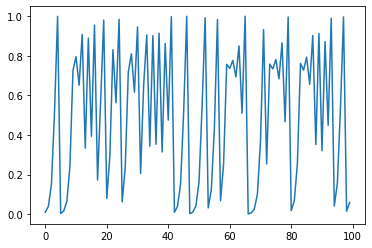

In [2]:
n = 100
x = np.zeros(n)

x[0] = 0.01
r = 4

for i in range(1,n): x[i] = (r*x[i-1])*(1-x[i-1]);
    
plt.plot(x)

for i in range(20): print("%f" % x[i]);

0.010000
0.626878
0.626418
0.619697
0.548784
0.380626
0.626904
0.626827
0.625640
0.609342
0.481567
0.456992
0.507021
0.415066
0.592965
0.422144
0.580162
0.397419
0.617633
0.532481


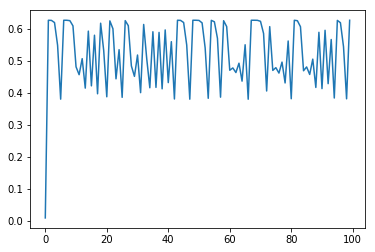

In [3]:
x1 = np.zeros(n)

x1[0] = 0.01
mu = 0
sigma = 1
nr = r/7

for i in range(1,n): x1[i] = (1+nr)* ( 1 / np.sqrt(2*np.pi*sigma**2) ) * ( np.e**-( ((x[i-1]-mu)**2) / (2*sigma**2) ) );
    
plt.plot(x1)

for i in range(20): print("%f" % x1[i]);

**Autómata celular elemental**

rule: 79(01001111)
iterations: 30
initial lattice: [1 0 0 0 0 0 1 0 0 0 0 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 1 0 0 1 0
 1 0 1 0 1 1 1 1 1]


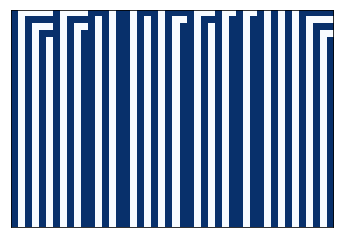

In [4]:
iterations = 30
max_size = 50
rule = random.randint(0,255)

def create_lattice(length):
    lattice = np.zeros((length,) , dtype=int)
    for i in range(length): lattice[i] = random.randint(0,1);
    return lattice

def evolve_lattice(lattice, generations):
    evolution_lattice = []
    evolution_lattice.append(lattice)
    for generation in range(generations):
        next_lattice = np.zeros((lattice.size,) , dtype=int)
        for i, v in enumerate(lattice):
            left = lattice[i-1] if (i > 0) else lattice[len(lattice)-1]
            center = v
            right = lattice[i+1] if (i < len(lattice)-1) else lattice[0]
            neighbors = left*2**2+center*2+right
            next_lattice[i] = format(rule, "08b")[7-neighbors]
        evolution_lattice.append(next_lattice)
        lattice = next_lattice
    return np.array(evolution_lattice)

def display_lattice(lattice):
    plt.xticks([]); plt.yticks([])
    plt.imshow(np.array(lattice).reshape(iterations+1, lattice[0].size), cmap=cm.Blues)
    print("rule: "+str(rule)+"("+format(rule, "08b")+")\niterations: "+str(iterations)+"\ninitial lattice: "+str(lattice[0]))

lattice = create_lattice(random.randint(1,max_size)) 
#lattice = np.array([0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0])
evolution_lattice = evolve_lattice(lattice, iterations)
display_lattice(evolution_lattice)

**Conway's Life**

iterations: 5


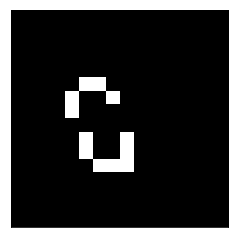

In [5]:
iterations = 5
max_size = 40

def create_life(size):
    life = np.zeros(shape=(size, size), dtype=int)
    for i in range(size): 
        for j in range(size): 
            life[i][j] = random.randint(0,1)
    return life

def evolve_life(life, generations):
    evolution_life = []
    evolution_life.append(life)
    for generation in range(generations):
        next_life = np.zeros(shape=(life[0].size, life[0].size) , dtype=int)
        for i, v in enumerate(life):
            for j, w in enumerate(life[i]):
                above_index = i-1 if (i > 0) else life[0].size-1
                bottom_index = i+1 if (i < life[0].size-1) else 0
                left_index = j-1 if (j > 0) else life[0].size-1
                right_index = j+1 if (j < life[0].size-1) else 0
                left_above = life[above_index][left_index]
                above = life[above_index][j]
                right_above = life[above_index][right_index]
                left_center = life[i][left_index]
                center = w
                right_center = life[i][right_index]
                left_bottom = life[bottom_index][left_index]
                bottom = life[bottom_index][j]
                right_bottom = life[bottom_index][right_index]
                neighbors_alive = left_above+above+right_above+left_center+right_center+left_bottom+bottom+right_bottom
                next_life[i][j] = 1 if ((center == 0 and neighbors_alive == 3) or (center == 1 and (neighbors_alive==2 or neighbors_alive==3))) else 0
        evolution_life.append(next_life)
        life = next_life
    return np.array(evolution_life)

def display_life(life):
    display.clear_output(wait=True)
    print("iterations: "+str(iterations))
    plt.xticks([]); plt.yticks([])
    plt.imshow(np.array(life).reshape(life[0].size, life[0].size), cmap=cm.gray)
    plt.pause(0.01)
    
def display_life_evolution(life):
    for i, v in enumerate(life): display_life(v);


life = np.array([
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

])
#life = create_life(random.randint(1,max_size))
evolution_life = evolve_life(life, iterations)
display_life_evolution(evolution_life)

**Nagel-Schreckenberg**

In [8]:
time = 150
no_cars = 4
max_speed = 10

class Car:
    def __init__(self, position, speed, next_car):
        self.position = position
        self.speed = speed
        self.next_car = next_car
        
    def __str__(self):
        return "{Position: "+str(self.position)+", Speed: "+str(self.speed)+", Distance to next car: "+str(self.next_car)+"}\n"
    
    def __repr__(self):
        return str(self)
    
def array_cars(cars):
    array_cars = [0] * cars[len(cars)-1].position
    for i in range(no_cars): array_cars[cars[i].position-1] = cars[i].speed;
    return array_cars

def numpy_cars(cars):
    np_cars = np.zeros((cars[len(cars)-1].position,) , dtype=int)
    for i in range(no_cars): np_cars[cars[i].position-1] = cars[i].speed;
    return np_cars
    
def create_cars(no_cars):
    cars = []
    car_position = 0
    next_car_distance = 0
    for i in range(no_cars):
        car_position = random.randint(0,5) if (i == 0) else car_position+next_car_distance
        next_car_distance = random.randint(1,5) if (i < no_cars-1) else max_speed
        cars.append(Car(car_position, random.randint(1,max_speed), next_car_distance))
    return cars

def evolve_cars(cars):
    evolution_cars = []
    evolution_cars.append(array_cars(cars))
    print(cars)
    for t in range(time):
        for i,car in reversed(list(enumerate(cars))):
            if (car.speed < max_speed): car.speed += 1;
            car.speed = min(car.next_car-1, car.speed)
            #PROB
            car.position = car.position + car.speed
        print(cars)
        evolution_cars.append(array_cars(cars))
    return evolution_cars

def display_cars(cars):
    print(cars)
    """
    display.clear_output(wait=True)
    print("iterations: "+str(time))
    plt.xticks([]); plt.yticks([])
    plt.imshow(np.array(cars).reshape(1, len(cars)), cmap=cm.Blues)
    plt.pause(1)
    """

def display_cars_evolution(cars):
    for i, v in enumerate(cars): display_cars(cars[i]);


cars = create_cars(no_cars)    
evolution_cars = evolve_cars(cars)
display_cars_evolution(evolution_cars)

[{Position: 4, Speed: 9, Distance to next car: 2}
, {Position: 6, Speed: 4, Distance to next car: 5}
, {Position: 11, Speed: 9, Distance to next car: 1}
, {Position: 12, Speed: 9, Distance to next car: 10}
]
[{Position: 5, Speed: 1, Distance to next car: 2}
, {Position: 10, Speed: 4, Distance to next car: 5}
, {Position: 11, Speed: 0, Distance to next car: 1}
, {Position: 21, Speed: 9, Distance to next car: 10}
]
[{Position: 6, Speed: 1, Distance to next car: 2}
, {Position: 14, Speed: 4, Distance to next car: 5}
, {Position: 11, Speed: 0, Distance to next car: 1}
, {Position: 30, Speed: 9, Distance to next car: 10}
]
[{Position: 7, Speed: 1, Distance to next car: 2}
, {Position: 18, Speed: 4, Distance to next car: 5}
, {Position: 11, Speed: 0, Distance to next car: 1}
, {Position: 39, Speed: 9, Distance to next car: 10}
]
[{Position: 8, Speed: 1, Distance to next car: 2}
, {Position: 22, Speed: 4, Distance to next car: 5}
, {Position: 11, Speed: 0, Distance to next car: 1}
, {Position

In [6]:
time = 1000
no_cars = 10
lane_size = 80
max_speed = 5

lane = np.full((lane_size), -1)

class Car:
    def __init__(self, position, speed, next_car):
        self.position = position
        self.speed = speed
        self.next_car = next_car
        
    def __str__(self):
        return "{Position: "+str(self.position)+", Speed: "+str(self.speed)+", Distance to next car: "+str(self.next_car)+"}\n"
    
    def __repr__(self):
        return str(self)
    
def array_cars(cars):
    array_cars = np.full((lane_size), -1)#[0] * cars[len(cars)-1].position
    for i in range(no_cars): array_cars[cars[i].position-1] = cars[i].speed;
    return array_cars
"""def numpy_cars(cars):
    np_cars = np.zeros((cars[len(cars)-1].position,) , dtype=int)
    for i in range(no_cars): np_cars[cars[i].position-1] = cars[i].speed;
    return np_cars"""

def create_cars(no_cars):
    cars = []
    car_position = 0
    next_car_distance = 0
    for i in range(no_cars):
        car_position = random.randint(0, max_speed) if (i == 0) else car_position+next_car_distance
        next_car_distance = random.randint(1, max_speed) if (i < no_cars-1) else max_speed
        car_speed = random.randint(1,max_speed)
        cars.append(Car(car_position, car_speed, next_car_distance))
        #lane[car_position] = car_speed
    return cars

def evolve_cars(cars):
    evolution_cars = []
    evolution_cars.append(array_cars(cars))
    #print(cars)
    for t in range(time):
        for i,car in reversed(list(enumerate(cars))):
            if (car.speed < max_speed): car.speed += 1;
            car.speed = min(car.next_car-1, car.speed) if (car.next_car > 1) else car.speed
            #PROB
            car.position = car.position + car.speed
            if (i > 0): cars[i-1].next_car += car.speed;
            if (i < len(cars)-1): car.next_car -= car.speed #if (cars[i-1].next_car-car.speed > 0): cars[i-1].next_car -= car.speed;
            if (int(car.position) >= lane_size): 
                car.position = 0
                car.speed = 0
                car.next_car = 1
                #cars.remove(car);
        #print(cars)
        evolution_cars.append(array_cars(cars))
    return evolution_cars

def display_cars(cars):
    #print(cars)
    display.clear_output(wait=True)
    print("iterations: "+str(time))
    plt.xticks([]); plt.yticks([])
    plt.imshow(np.array(cars).reshape(1, len(cars)), cmap=cm.Blues)
    plt.pause(0.1)

def display_cars_evolution(cars):
    for i, v in enumerate(cars): display_cars(cars[i]);

cars = create_cars(no_cars)
evolution_cars = evolve_cars(cars)
display_cars_evolution(evolution_cars)

iterations: 1000
